## Comparing dense matrix operations against sparse edge-list representations


**Goals**  
1. Implement cutoff-based thresholding to construct adjacency matrices ($\mathbf{A}_{ij} \in \{0, 1\}$) from distance matrices ($\mathbf{D}_{ij}$).
2. Convert dense adjacency matrices into PyTorch Geometric-compatible COO `edge_index` tensors ($\mathbb{Z}^{2 \times E}$).
3. Benchmark memory and execution speed scaling across $O(N^2)$ dense formats vs. $O(E)$ sparse representations on Par-6 and Lgl across cutoffs ($6.0\text{ Å}, 8.0\text{ Å}, 10.0\text{ Å}, 12.0\text{ Å}$).

**Background**  
Using dense distance matrices, we can capture which residues are within interaction range by constructing an **adjacency matrix**—a square matrix used to represent a finite graph. In an adjacency matrix, rows and columns represent vertices (residues), and non-zero entries represent edges (interactions). In a protein contact map, when a pair of residues falls within a defined spatial cutoff, a $1$ represents an edge and a $0$ represents a non-edge.

Generating a dense adjacency matrix requires evaluating every pair of residues and explicitly storing both edges and non-edges. Because it uses a fixed $N \times N$ grid, the memory required scales quadratically at $O(N^2)$ space complexity as protein size grows.

However, proteins are sparsely connected spatially: most residues only interact with immediate spatial neighbors within a local distance cutoff (e.g., $R_c = 8.0\,\text{Å}$ or $10.0\,\text{Å}$). Consequently, storing a dense $N \times N$ adjacency matrix is memory-inefficient, as the vast majority of entries are zeros. To optimize memory footprint and downstream computations, we can discard the zeros and store only active connections using sparse COO format (e.g., PyTorch Geometric's `edge_index` of shape $\mathbb{Z}^{2 \times E}$), reducing the memory footprint from $O(N^2)$ down to $O(E)$ space complexity (where $E \ll N^2$).

**Experiments**  
We will benchmark these two methods across Par-6 ($N=94$) and Lgl ($N=860$) to quantify memory footprint and generation latency.

### Results Summary
The following table shows the results of benchmarking dense matrix and sparse matrix for both Par-6 and Lgl.

| Protein   |   Residues (N) |   Cutoff (Å) |   Edges (E) |   Density (%) |   Dense Mem (KB) |   Sparse Mem (KB) |   Mem Reduction (x) |   Dense Time (ms) |   Sparse Time (ms) |
|:----------|---------------:|-------------:|------------:|--------------:|-----------------:|------------------:|--------------------:|------------------:|-------------------:|
| Par-6     |             94 |         6.00 |         424 |          4.80 |            69.03 |              6.62 |               10.42 |              0.06 |               0.07 |
| Par-6     |             94 |         8.00 |         818 |          9.26 |            69.03 |             12.78 |                5.40 |              0.04 |               0.06 |
| Par-6     |             94 |        10.00 |        1310 |         14.83 |            69.03 |             20.47 |                3.37 |              0.05 |               0.06 |
| Par-6     |             94 |        12.00 |        2088 |         23.63 |            69.03 |             32.62 |                2.12 |              0.03 |               0.08 |
| Lgl       |            860 |         6.00 |        4156 |          0.56 |          5778.12 |             64.94 |               88.98 |              1.90 |               0.99 |
| Lgl       |            860 |         8.00 |        8458 |          1.14 |          5778.12 |            132.16 |               43.72 |              1.94 |               0.81 |
| Lgl       |            860 |        10.00 |       15254 |          2.06 |          5778.12 |            238.34 |               24.24 |              1.66 |               0.88 |
| Lgl       |            860 |        12.00 |       25870 |          3.50 |          5778.12 |            404.22 |               14.29 |              1.57 |               0.79 |

### Key Insights  
1. Memory Footprint & Asymptotics ($O(N^2)$ vs. $O(E)$):
- Dense matrices incur a fixed memory penalty proportional strictly to $N^2$, regardless of interaction threshold ($69.03\text{ KB}$ for Par-6; $5,778.12\text{ KB}$ for Lgl).
- Sparse COO lists scale linearly with the number of realized edges ($2 \times E$). For Lgl ($N=860$) at a standard $6.0\text{ Å}$ cutoff, sparse representation yields an $88.98\times$ memory reduction ($64.94\text{ KB}$ vs. $5,778.12\text{ KB}$). Even at a loose $12.0\text{ Å}$ threshold, sparse COO preserves a $14.29\times$ memory advantage.
2. Sparsity of Biological Macromolecules:
- As protein size increases, local spatial cutoffs become dramatically more sparse. Lgl's contact density ranges from $0.56\%$ to $3.50\%$, meaning over $96\%$ of a dense $N \times N$ matrix consists of redundant zeros.
3. Generation Latency & Crossover Point:
- Small Systems (Par-6, $N=94$): Dense mask creation is marginally faster ($\sim 0.04\text{ ms}$ vs. $\sim 0.07\text{ ms}$) because the overhead of index extraction (torch.nonzero) slightly exceeds the cost of allocating a tiny $94 \times 94$ tensor.
- Large Systems (Lgl, $N=860$): Sparse COO construction is $\approx 2\times$ faster ($\sim 0.81\text{ ms}$ vs. $\sim 1.94\text{ ms}$) because sparse indexing avoids generating and storing dense zero-value allocations across $739,600$ pairs.

### Conclusions
These benchmark results clearly illustrate the trade-offs between dense adjacency matrices and sparse COO edge lists across protein scales and interaction radii.

For our `polarity-engine` pipeline, we should use both dense matrix and sparse matrix depending on the use cases. 
- Message Passing & Geometric Deep Learning: Standardize on Sparse COO (edge_index of shape [2, E]). The linear $O(E)$ space complexity prevents GPU memory saturation when batching large protein graphs like Lgl.
- Normal Mode Analysis & ANM: Reserve Dense Adjacency matrices exclusively for dense linear algebra operations (such as full Hessian matrix diagonalization or Kirchhoff matrix inversion) where dense contiguous memory layout is required by C++/LAPACK backends.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from collections.abc import Callable
from pathlib import Path
from scipy import stats
from statannotations.Annotator import Annotator
from typing import Any

from polarity_engine.parsers import StructureParser

In [3]:
data_dir = Path("../../data")
data_dir.mkdir(parents=True, exist_ok=True)

input_dir = data_dir / "input"
input_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# Ensure float64 precision standard from notebook 01
torch.set_default_dtype(torch.float64)

### Prepare the coordinate data to be used in the experiments

In [5]:
TEST_CIF_Paht = input_dir / "8r3y.cif"
test_coords = StructureParser.get_alpha_carbon_coordinates(TEST_CIF_Paht)

par6_coords = test_coords["P"]["coords"]
lgl_coords = test_coords["L"]["coords"]


In [6]:
def distance_to_dense_adjacency(
        dist_matrix: torch.Tensor,
        cutoff: float = 8.0,
        include_self_loops: bool = False
) -> torch.Tensor:
    """
    Converts a dense pairwise distance matrix into a binary dense adjacency matrix.

    Args:
        dist_matrix: (N, N) distance tensor.
        cutoff: Distance threshold in Angstroms.
        include_self_loops: Whether diagonal elements (i == j) should be 1.

    Returns:
        adj: (N, N) binary tensor where 1 indicates an edge within cutoff.
    """
    adj = (dist_matrix <= cutoff).to(torch.int64)

    if not include_self_loops:
        adj.fill_diagonal_(0)

    return adj


def distance_to_sparse_coo(
        dist_matrix: torch.Tensor,
        cutoff: float = 8.0,
        include_self_loops: bool = False
) -> tuple[torch.Tensor, int]:
    """
    Converts a dense pairwise distance matrix directly to PyTorch Geometric COO edge_index format.

    Args:
        dist_matrix: (N, N) distance tensor.
        cutoff: Distance threshold in Angstroms.
        include_self_loops: Whether diagonal elements should be retained.

    Returns:
        edge_index: (2, E) tensor containing source and target node indices.
        num_edges: Total number of active edges E.
    """
    mask = dist_matrix <= cutoff

    if not include_self_loops:
        mask.fill_diagonal_(False)

    # torch.nonzero returns (E, 2) indices -> transpose to (2, E) for PyG standard
    # .contiguous() forces PyTorch to rearrange the data sequentially in memory,
    edge_index = torch.nonzero(mask).t().contiguous()
    num_edges = edge_index.shape[1]

    return edge_index, num_edges

In [7]:
def benchmark_representation(
    coords_np: np.ndarray,
    protein_name: str,
    cutoffs: list[float] = [6.0, 8.0, 10.0, 12.0],
    num_runs: int = 50,
) -> pd.DataFrame:
    """
    Benchmarks memory footprint and generation latency for Dense Adjacency vs Sparse COO.

    Args:
        coords_np: a numpy array of dense distance matrix
        protein_name: a name of protein
        cutoffs: a list of cutoffs to use as threshold for generating adjacency matrix
        num_run: a number of runs to measure performance

    Returns:
        detailed scaling metrics for Par-6 and Lgl.
    """
    coords = torch.from_numpy(coords_np).double()
    N = coords.shape[0]
    total_possible_edges = N * N

    # Calculate distance matrix ONCE using torch.cdist (established in notebook 01)
    dist_matrix = torch.cdist(coords, coords)

    results = []

    for rc in cutoffs:
        # --- A. Dense Benchmarks ---
        t0 = time.perf_counter()
        for _ in range(num_runs):
            dense_adj = distance_to_dense_adjacency(dist_matrix, cutoff=rc)
        dense_time = (time.perf_counter() - t0) / num_runs * 1000  # ms

        # Dense memory calculation (N x N int64)
        dense_mem_kb = (dense_adj.element_size() * dense_adj.nelement()) / 1024

        # --- B. Sparse COO Benchmarks ---
        t0 = time.perf_counter()
        for _ in range(num_runs):
            edge_index, num_edges = distance_to_sparse_coo(dist_matrix, cutoff=rc)
        sparse_time = (time.perf_counter() - t0) / num_runs * 1000  # ms

        # Sparse COO memory calculation (2 x E int64)
        sparse_mem_kb = (edge_index.element_size() * edge_index.nelement()) / 1024

        # Calculate graph density percentage E / N^2
        edge_density = (num_edges / total_possible_edges) * 100

        results.append(
            {
                "Protein": protein_name,
                "Residues (N)": N,
                "Cutoff (Å)": rc,
                "Edges (E)": num_edges,
                "Density (%)": round(edge_density, 2),
                "Dense Mem (KB)": round(dense_mem_kb, 2),
                "Sparse Mem (KB)": round(sparse_mem_kb, 2),
                "Mem Reduction (x)": round(dense_mem_kb / max(sparse_mem_kb, 1e-6), 2),
                "Dense Time (ms)": round(dense_time, 4),
                "Sparse Time (ms)": round(sparse_time, 4),
            }
        )

    return pd.DataFrame(results)

In [12]:
df_par6 = benchmark_representation(par6_coords, "Par-6")
df_lgl = benchmark_representation(lgl_coords, "Lgl")

df_benchmark = pd.concat([df_par6, df_lgl], ignore_index=True)
print(df_benchmark.to_markdown(index=False, floatfmt=".2f"))

| Protein   |   Residues (N) |   Cutoff (Å) |   Edges (E) |   Density (%) |   Dense Mem (KB) |   Sparse Mem (KB) |   Mem Reduction (x) |   Dense Time (ms) |   Sparse Time (ms) |
|:----------|---------------:|-------------:|------------:|--------------:|-----------------:|------------------:|--------------------:|------------------:|-------------------:|
| Par-6     |             94 |         6.00 |         424 |          4.80 |            69.03 |              6.62 |               10.42 |              0.06 |               0.07 |
| Par-6     |             94 |         8.00 |         818 |          9.26 |            69.03 |             12.78 |                5.40 |              0.04 |               0.06 |
| Par-6     |             94 |        10.00 |        1310 |         14.83 |            69.03 |             20.47 |                3.37 |              0.05 |               0.06 |
| Par-6     |             94 |        12.00 |        2088 |         23.63 |            69.03 |             32.

In [9]:
df_mem_long = pd.melt(
    df_benchmark,
    id_vars=["Protein", "Cutoff (Å)"],
    value_vars=["Dense Mem (KB)", "Sparse Mem (KB)"],
    var_name="Format",
    value_name="Memory (KB)",
)

# Clean up 'Format' column values for the legend
df_mem_long["Format"] = df_mem_long["Format"].str.replace(" Mem (KB)", "")

df_time_long = pd.melt(
    df_benchmark,
    id_vars=["Protein", "Cutoff (Å)"],
    value_vars=["Dense Time (ms)", "Sparse Time (ms)"],
    var_name="Format",
    value_name="Time (ms)",
)

# Clean up 'Format' column values for the legend
df_time_long["Format"] = df_time_long["Format"].str.replace(" Time (ms)", "")

Text(0.5, 0.98, 'Comparisons of Performance between Dense Adjacency Matrix Representation and Sparse Representation')

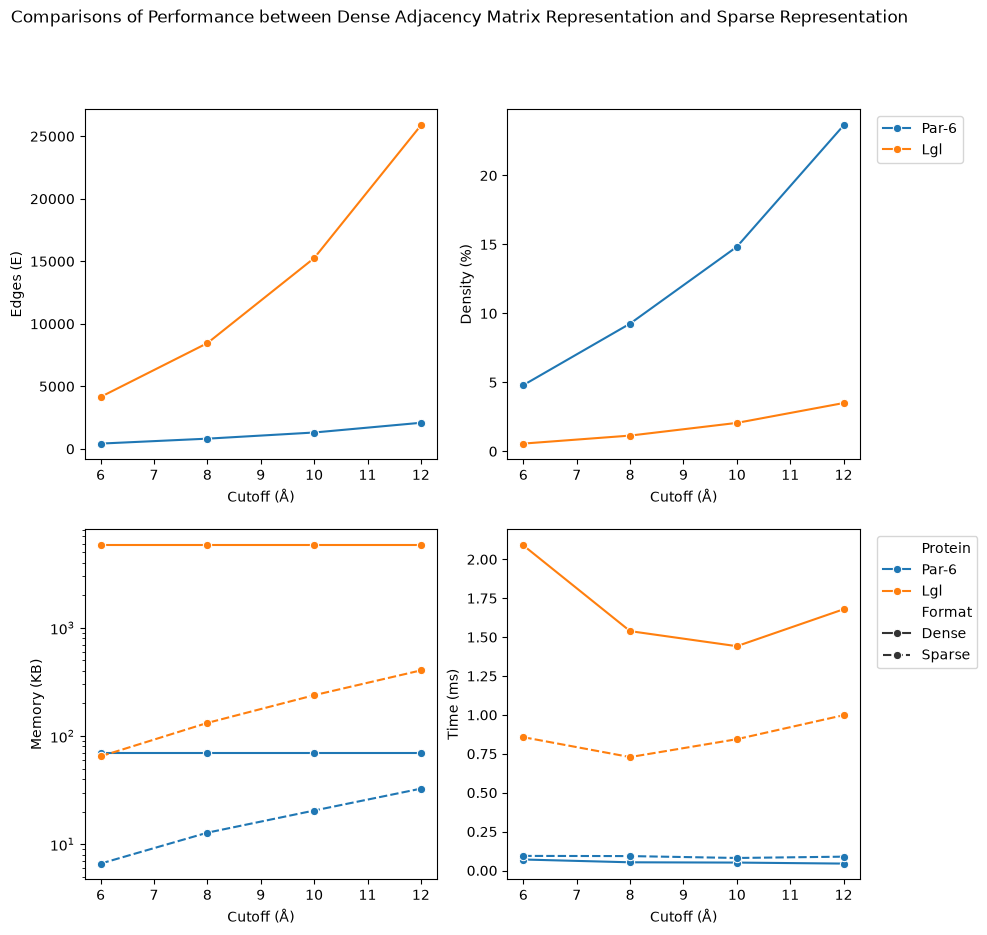

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

sns.lineplot(data=df_benchmark, x="Cutoff (Å)",
             y="Edges (E)", hue="Protein", legend=None, marker='o', ax=axs[0, 0])
sns.lineplot(data=df_benchmark, x="Cutoff (Å)",
             y="Density (%)", hue="Protein", marker='o', ax=axs[0, 1])
axs[0, 1].legend(bbox_to_anchor=(1.03, 1))
sns.lineplot(data=df_mem_long, x="Cutoff (Å)",
             y="Memory (KB)", hue="Protein", style="Format", marker='o', legend=None, ax=axs[1, 0])
axs[1, 0].set_yscale("log")
sns.lineplot(data=df_time_long, x="Cutoff (Å)",
             y="Time (ms)", hue="Protein", style="Format", marker='o', ax=axs[1, 1])
axs[1, 1].legend(bbox_to_anchor=(1.03, 1))

fig.suptitle(
    "Comparisons of Performance between Dense Adjacency Matrix Representation and Sparse Representation")